# Project 2 - Autoregressive forecast with autocorrelated loads for a 10 port network

<b>Import Python Libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>Parameters

In [86]:
networkFactor = 100    # To change the characteristics of the network (Y)
cosPhi=0.95            # Value of teta
time=24                # Training Period  
timeForecast=12        # Test Period

<b>Import data (From Excel file)

In [87]:
Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n")

# Network Information
Net_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (Train)
Power_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Info, "\n")

#Power Information (Test)
Power_Test = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Test_Load(t,Bus)'))
Power_Test = np.delete(Power_Test,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Test, "\n")

P = np.dot(-Power_Info, np.exp(complex(0,1)*np.arccos(cosPhi)))  # shape (13, 9)
I = np.conj(P[0, :])   # row 0 = first time step, all 9 buses → shape (9,)


Slack Bus:  1 

Lines information (Admitances)
 [[1 2 '0,01-0,10i']
 [2 3 '0,02-0,15i']
 [3 4 '0,02-0,15i']
 [4 5 '0,03-0,20i']
 [2 6 '0,02-0,18i']
 [3 6 '0,03-0,22i']
 [3 7 '0,03-0,22i']
 [4 7 '0,02-0,18i']
 [6 8 '0,04-0,25i']
 [7 9 '0,04-0,25i']
 [8 10 '0,05-0,30i']
 [9 10 '0,05-0,30i']] 

Power consumption information (time, Bus)
 [[0.5   0.8   0.6   0.3   0.7   0.4   0.5   0.4   0.3  ]
 [0.5   0.707 0.568 0.329 0.298 0.603 0.463 0.439 0.287]
 [0.404 0.324 0.414 0.287 0.165 0.394 0.445 0.375 0.295]
 [0.44  0.366 0.23  0.217 0.068 0.267 0.276 0.493 0.348]
 [0.603 0.167 0.305 0.193 0.03  0.239 0.27  0.387 0.391]
 [0.477 0.072 0.445 0.03  0.03  0.142 0.273 0.656 0.208]
 [0.371 0.03  0.546 0.03  0.11  0.03  0.125 0.632 0.092]
 [0.552 0.47  0.313 0.058 0.49  0.034 0.386 0.435 0.125]
 [0.584 0.396 0.21  0.182 0.453 0.03  0.399 0.241 0.152]
 [0.426 0.083 0.239 0.108 0.439 0.082 0.161 0.263 0.176]
 [0.444 0.268 0.378 0.03  0.358 0.03  0.235 0.197 0.496]
 [0.308 0.03  0.235 0.03  0.03  0.211

<b>Admittance Matrix(<i>Y</i>); Conductance Matrix(<i>G</i>); Susceptance Matrix(<i>B</i>)

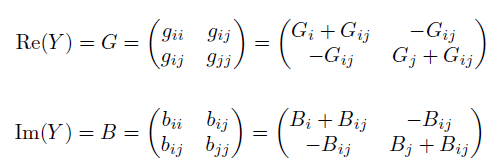

In [88]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 

print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")

The admitance matrix Y is:
 [[ 1.-10.j -1.+10.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [-1.+10.j  5.-43.j -2.+15.j  0. +0.j  0. +0.j -2.+18.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j -2.+15.j 10.-74.j -2.+15.j  0. +0.j -3.+22.j -3.+22.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -2.+15.j  7.-53.j -3.+20.j  0. +0.j -2.+18.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j -3.+20.j  3.-20.j  0. +0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j -2.+18.j -3.+22.j  0. +0.j  0. +0.j  9.-65.j  0. +0.j -4.+25.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+22.j -2.+18.j  0. +0.j  0. +0.j  9.-65.j  0. +0.j
  -4.+25.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -4.+25.j  0. +0.j  9.-55.j
   0. +0.j -5.+30.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -4.+25.j  0. +0.j
   9.-55.j -5.+30.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -5.+30.j
  -5.+30.j 10.-60.j]] 

The conductance mat

<b> Errors Definition

Random values considering a normal distribution

In [89]:
np.random.seed(50)
e1=np.random.randn(time+timeForecast)*0.5  #Errors associated to Wind Generation
e=np.random.randn(time+timeForecast)*0.25  #Errors associated to Power Injection (Consumption) 
e2 = np.random.randn(time+timeForecast)*0.5 #Errors associated to Power Injection (Consumption) in the test period

To obtain the same values of lecture notes, we should use the following errors

<b> Determine the wind generation and the load flow in <i>I<sub>12

In [90]:
# AUTOCORRELATION DEFINITION:

# Before the loop, add an error state vector:
eta = np.zeros((nBus-1, time+timeForecast), dtype=complex)
rho_load = 0.7   # autocorrelation in the load error — tune this between 0.5 and 0.9


# Before the loop:
eta_pv1 = np.zeros(time+timeForecast)
eta_pv2 = np.zeros(time+timeForecast)
rho_pv  = 0.6

#Creation of Matrix
II = np.zeros((nBus-1, time+timeForecast), dtype=complex)
lines = [
    (1,2),(2,3),(3,4),(4,5),
    (2,6),(3,6),(3,7),(4,7),
    (6,8),(7,9),(8,10),(9,10)
]
I_lines = np.zeros((len(lines), time+timeForecast))
i_pv1   = np.zeros(time+timeForecast)   # PV source at Bus 5 (index 3 after slack removed)
i_pv2   = np.zeros(time+timeForecast)   # PV source at Bus 7 (index 5 after slack removed)

# Initializing the process of data generation
II[:,0]=I                                      #Power Injections
v = 1+np.dot(np.linalg.inv(Yl),I)
v_full = np.insert(v, SlackBus-1, 1.0+0j)          # reinsert slack bus voltage
i_pv1[0] = np.real(I[3])                            # Bus 5 is index 3 (slack Bus 1 removed)
i_pv2[0] = np.real(I[5])                            # Bus 7 is index 5
for k, (bi, bj) in enumerate(lines):
    I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
    I_lines[k, 0] = np.absolute(I_flow) * np.sign(np.real(I_flow))

# Process of data generation
for t in range(time+timeForecast-1):             
    # Inside the loop, replace the II update line with:
    eta[:, t+1] = rho_load * eta[:, t] + e[t]
    II[:, t+1]  = 0.95*II[:, t] + eta[:, t+1]



    # CORRELATION LINES
    eta_pv1[t+1]  = rho_pv * eta_pv1[t] + e1[t]
    eta_pv2[t+1]  = rho_pv * eta_pv2[t] + e2[t]
    i_pv1[t+1]    = 0.75*i_pv1[t] + eta_pv1[t+1]
    i_pv2[t+1]    = 0.75*i_pv2[t] + eta_pv2[t+1]


    II[3,t+1] = i_pv1[t+1]+complex(0,np.imag(II[3,t+1]))   # Bus 5 injection
    II[5,t+1] = i_pv2[t+1]+complex(0,np.imag(II[5,t+1]))   # Bus 7 injection
    v      = 1+np.dot(np.linalg.inv(Yl),II[:,t+1])
    v_full = np.insert(v, SlackBus-1, 1.0+0j)
    for k, (bi, bj) in enumerate(lines):
        I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
        I_lines[k, t+1] = np.absolute(I_flow) * np.sign(np.real(I_flow))

    
print('The power injection in Bus 5 (PV1) is:\n', i_pv1)
print('The power injection in Bus 7 (PV2) is:\n', i_pv2)
for k, (bi, bj) in enumerate(lines):
    print(f'Power flow in Line {bi}-{bj}:\n', I_lines[k,:])

The power injection in Bus 5 (PV1) is:
 [-2.85000000e-01 -9.93926054e-01 -1.22903898e+00 -1.52240010e+00
 -2.23446284e+00 -1.62547173e+00 -1.42724463e+00 -1.58555258e+00
 -9.63102029e-01 -1.22783538e+00 -1.88792130e+00 -1.93299901e+00
 -1.32888722e+00 -5.75779715e-01 -3.46585957e-01 -7.07553202e-01
  2.21004382e-04  1.97573497e+00  3.16102799e+00  3.44024018e+00
  3.59325434e+00  3.10580735e+00  2.64993338e+00  1.97367953e+00
  1.39163982e+00  1.06032370e+00  9.47933761e-01  6.61933916e-01
  1.32249425e+00  1.41261366e+00  1.65705939e+00  2.14895878e+00
  2.82462198e+00  2.16171739e+00  1.89045240e+00  1.95609875e+00]
The power injection in Bus 7 (PV2) is:
 [-0.38        0.06896304  0.51109502  1.39444575  1.36119926  2.24302817
  2.9594653   3.38851     2.44878669  2.39647529  0.94656094  0.1838879
 -2.08264895 -2.99385048 -2.92929075 -2.63358519 -2.55429971 -2.44465682
 -3.43631172 -3.47016789 -3.49803447 -2.79650954 -1.39029962  0.14235593
  0.16442862 -0.28696569 -0.45876268 -0.056

<b>Ordinary Least Squares OLS regression
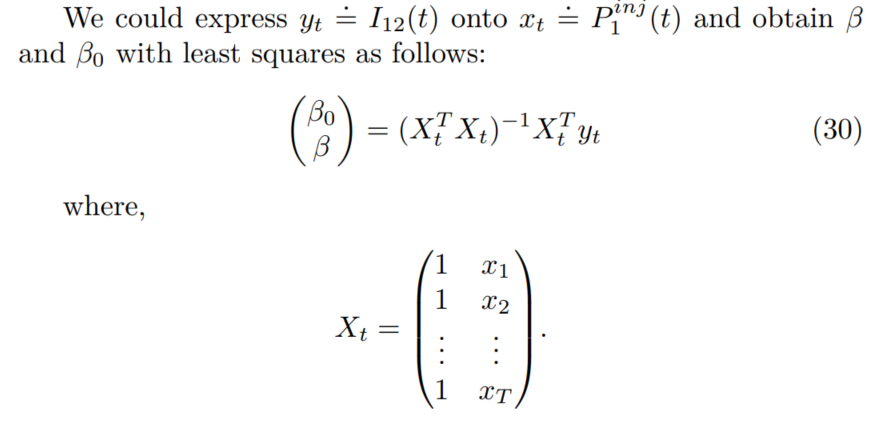

<b>Durbin-Watson statistic
    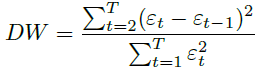

- The Durbin Watson statistic is a test for autocorrelation in a data set.
- The DW statistic always has a value between zero and 4.0.
- A value of 2.0 means there is no autocorrelation detected in the sample. Values from zero to 2.0 indicate positive autocorrelation and values from 2.0 to 4.0 indicate negative autocorrelation.

<sub>https://www.investopedia.com/terms/d/durbin-watson-statistic.asp

<b>Cochrane Orcutt
   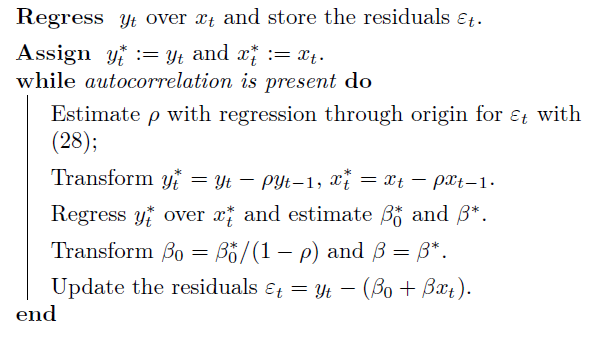

<b>Forecast Day-ahead (Current I_12)

<b>Plot forecsated values

<b>Autocorrelation Method 
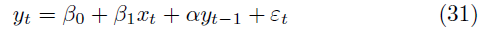
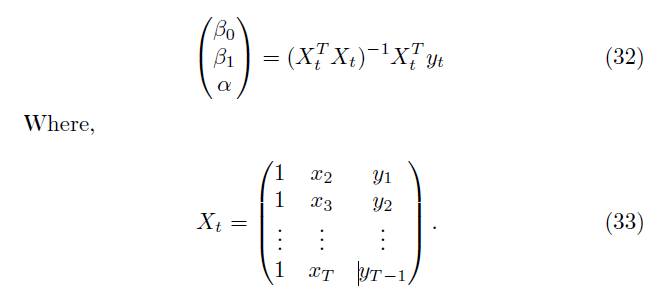

In this example, the input data is different because the error used to generate the values is different. To obtain the same results, we should use the next values. To compare with previous example, we can skip this step.

<b> Models
- 1 - OLS 
- 2 - Cochrane Orcutt (CO)
- 3 - Autorregration AR(1) 
- 4 - Autorregration with Loads AR(1)+Load Sum

## Solvers

In [91]:
nL = len(lines)

# Storage for betas and residuals across all lines and methods
beta_OLS     = np.zeros((nL, 3))        # intercept + pv1 + pv2
beta_CO_all  = np.zeros((nL, 3))
beta_AR1_all = np.zeros((nL, 4))        # intercept + pv1 + pv2 + lagged line current
beta_AR1L_all= np.zeros((nL, 5))        # intercept + pv1 + pv2 + lagged + load sum

resid_OLS    = np.zeros((nL, timeForecast))
resid_CO     = np.zeros((nL, timeForecast))
resid_AR1    = np.zeros((nL, timeForecast-1))
resid_AR1L   = np.zeros((nL, timeForecast-1))

DW_OLS  = np.zeros(nL)
DW_CO   = np.zeros(nL)
DW_AR1  = np.zeros(nL)
DW_AR1L = np.zeros(nL)

In [92]:
# Load sum regressor: sum of real power injections across all non-PV, non-slack buses
# (buses 2,3,4,6,8,9,10 → indices 1,2,3,5,7,8 in II after slack removed)
load_indices = [1, 2, 3, 5, 7, 8]
load_sum = np.sum(np.real(II[load_indices, :]), axis=0)  # shape (time+timeForecast,)

for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]   # current in line k, full time series

    # ── 1. OLS ───────────────────────────────────────────────────────────────
    Xt = np.ones((time, 3))
    Xt[:, 1] = i_pv1[0:time]
    Xt[:, 2] = i_pv2[0:time]
    XtT = np.transpose(Xt)
    b = np.dot(np.dot(np.linalg.inv(np.dot(XtT, Xt)), XtT), iL[0:time])
    beta_OLS[k] = b

    epsilon = iL[0:time] - (b[0] + b[1]*i_pv1[0:time] + b[2]*i_pv2[0:time])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_OLS[k] = np.divide(dw1, dw2)

    iL_out_OLS = b[0] + b[1]*i_pv1[time:time+timeForecast] + b[2]*i_pv2[time:time+timeForecast]
    resid_OLS[k] = iL[time:time+timeForecast] - iL_out_OLS

    # ── 2. Cochrane-Orcutt ───────────────────────────────────────────────────
    res_1 = iL[0:time] - (b[0] + b[1]*i_pv1[0:time] + b[2]*i_pv2[0:time])
    for _ in range(3):
        r2 = res_1[0:time-1]
        r1 = res_1[1:time]
        ro = np.dot(np.dot((np.dot(r2, r2))**(-1), r2), r1)

        iL_s   = iL[1:time]   - ro*iL[0:time-1]
        pv1_s  = i_pv1[1:time] - ro*i_pv1[0:time-1]
        pv2_s  = i_pv2[1:time] - ro*i_pv2[0:time-1]

        B_co = np.ones((time-1, 3))
        B_co[:, 1] = pv1_s
        B_co[:, 2] = pv2_s
        BtB = np.dot(np.transpose(B_co), B_co)
        b_s = np.dot(np.dot(np.linalg.inv(BtB), np.transpose(B_co)), iL_s)
        b_s[0] = b_s[0] / (1 - ro)

        res_2 = iL[0:time] - (b_s[0] + b_s[1]*i_pv1[0:time] + b_s[2]*i_pv2[0:time])
        res_1 = res_2[:]
    beta_CO_all[k] = b_s

    epsilon = iL[0:time] - (b_s[0] + b_s[1]*i_pv1[0:time] + b_s[2]*i_pv2[0:time])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_CO[k] = np.divide(dw1, dw2)

    iL_out_CO = b_s[0] + b_s[1]*i_pv1[time:time+timeForecast] + b_s[2]*i_pv2[time:time+timeForecast]
    resid_CO[k] = iL[time:time+timeForecast] - iL_out_CO

    # ── 3. AR(1) ─────────────────────────────────────────────────────────────
    Xt_AR = np.ones((time-1, 4))
    Xt_AR[:, 1] = i_pv1[1:time]
    Xt_AR[:, 2] = i_pv2[1:time]
    Xt_AR[:, 3] = iL[0:time-1]          # lagged line current
    XtT_AR = np.transpose(Xt_AR)
    b_AR = np.dot(np.dot(np.linalg.inv(np.dot(XtT_AR, Xt_AR)), XtT_AR), iL[1:time])
    beta_AR1_all[k] = b_AR

    epsilon = iL[1:time] - (b_AR[0] + b_AR[1]*i_pv1[1:time] + b_AR[2]*i_pv2[1:time] + b_AR[3]*iL[0:time-1])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_AR1[k] = np.divide(dw1, dw2)

    iL_out_AR1 = (b_AR[0] + b_AR[1]*i_pv1[time+1:time+timeForecast]
                           + b_AR[2]*i_pv2[time+1:time+timeForecast]
                           + b_AR[3]*iL[time:time+timeForecast-1])
    resid_AR1[k] = iL[time+1:time+timeForecast] - iL_out_AR1

    # ── 4. AR(1) + Load Sum ──────────────────────────────────────────────────
    Xt_ARL = np.ones((time-1, 5))
    Xt_ARL[:, 1] = i_pv1[1:time]
    Xt_ARL[:, 2] = i_pv2[1:time]
    Xt_ARL[:, 3] = iL[0:time-1]
    Xt_ARL[:, 4] = load_sum[1:time]
    XtT_ARL = np.transpose(Xt_ARL)
    b_ARL = np.dot(np.dot(np.linalg.inv(np.dot(XtT_ARL, Xt_ARL)), XtT_ARL), iL[1:time])
    beta_AR1L_all[k] = b_ARL

    epsilon = (iL[1:time] - (b_ARL[0] + b_ARL[1]*i_pv1[1:time] + b_ARL[2]*i_pv2[1:time]
                             + b_ARL[3]*iL[0:time-1] + b_ARL[4]*load_sum[1:time]))
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_AR1L[k] = np.divide(dw1, dw2)

    iL_out_ARL = (b_ARL[0] + b_ARL[1]*i_pv1[time+1:time+timeForecast]
                            + b_ARL[2]*i_pv2[time+1:time+timeForecast]
                            + b_ARL[3]*iL[time:time+timeForecast-1]
                            + b_ARL[4]*load_sum[time+1:time+timeForecast])
    resid_AR1L[k] = iL[time+1:time+timeForecast] - iL_out_ARL

# ── Summary print ─────────────────────────────────────────────────────────────
for k, (bi, bj) in enumerate(lines):
    print(f"\nLine {bi}-{bj}:")
    print(f"  OLS  betas={np.round(beta_OLS[k],4)}  DW={DW_OLS[k]:.4f}")
    print(f"  CO   betas={np.round(beta_CO_all[k],4)}  DW={DW_CO[k]:.4f}")
    print(f"  AR1  betas={np.round(beta_AR1_all[k],4)}  DW={DW_AR1[k]:.4f}")
    print(f"  AR1L betas={np.round(beta_AR1L_all[k],4)}  DW={DW_AR1L[k]:.4f}")


Line 1-2:
  OLS  betas=[ 2.632  -2.0372 -3.0757]  DW=1.1656
  CO   betas=[ 2.7275 -2.0038 -2.8893]  DW=1.0093
  AR1  betas=[ 1.7967 -1.7483 -2.3859  0.2655]  DW=1.2376
  AR1L betas=[ 0.1457  0.567   0.5278  0.0226 -1.6396]  DW=1.7426

Line 2-3:
  OLS  betas=[ 1.0745 -0.986  -1.3764]  DW=1.1546
  CO   betas=[ 1.1135 -0.968  -1.2968]  DW=0.9967
  AR1  betas=[ 0.7722 -0.8554 -1.1068  0.2303]  DW=1.2304
  AR1L betas=[ 0.0595  0.0847  0.1005  0.0146 -0.6752]  DW=1.6263

Line 3-4:
  OLS  betas=[ 0.3163 -0.6906 -0.4705]  DW=1.2458
  CO   betas=[ 0.3286 -0.682  -0.4468]  DW=1.1080
  AR1  betas=[ 0.2588 -0.614  -0.4097  0.1393]  DW=1.3155
  AR1L betas=[-0.0118 -0.3414  0.0126 -0.0109 -0.2257]  DW=2.2374

Line 4-5:
  OLS  betas=[ 6.000e-04 -9.995e-01  1.200e-03]  DW=1.9159
  CO   betas=[-0.     -0.9994  0.0012]  DW=1.9004
  AR1  betas=[ 1.0000e-04 -1.0016e+00  1.0000e-03 -2.1000e-03]  DW=2.2127
  AR1L betas=[ 7.5000e-03 -1.0082e+00 -9.9000e-03 -8.0000e-04  5.1000e-03]  DW=2.5142

Line 2-6:
  OL

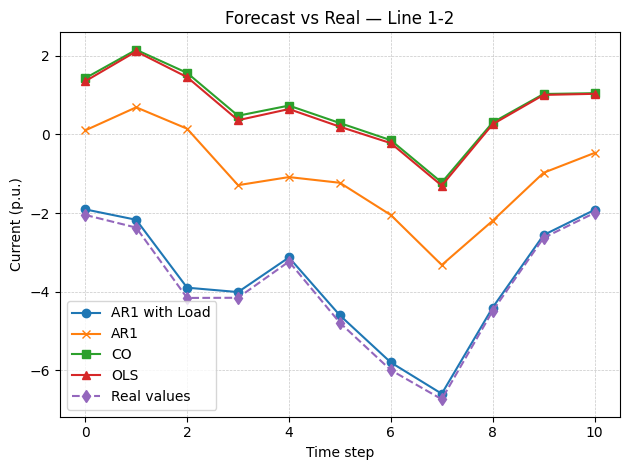

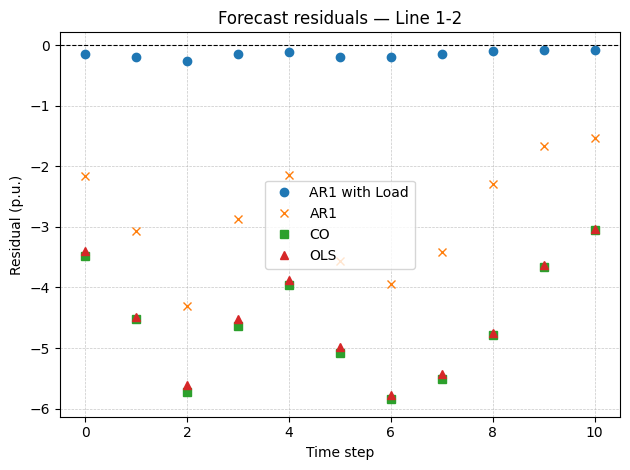

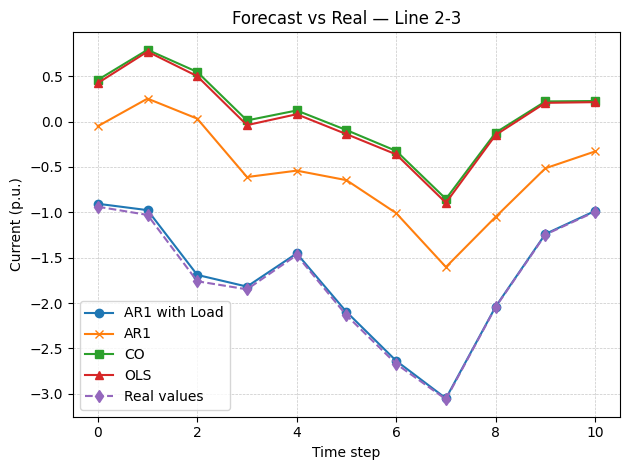

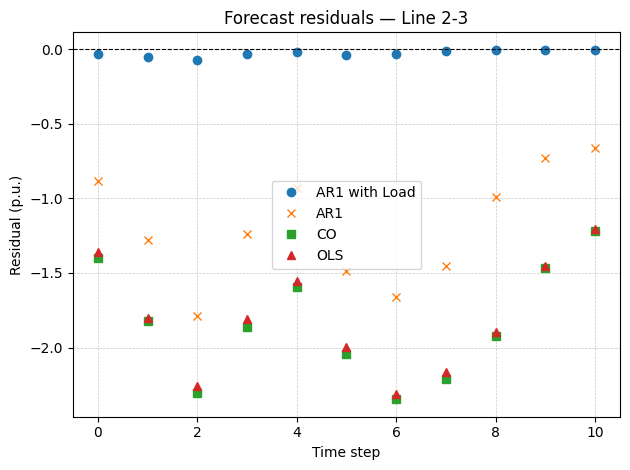

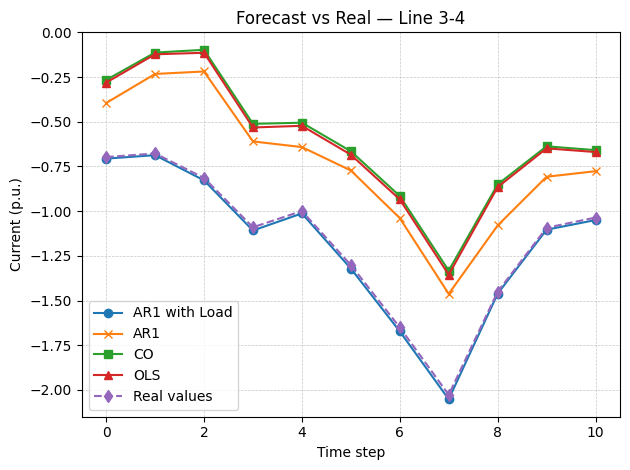

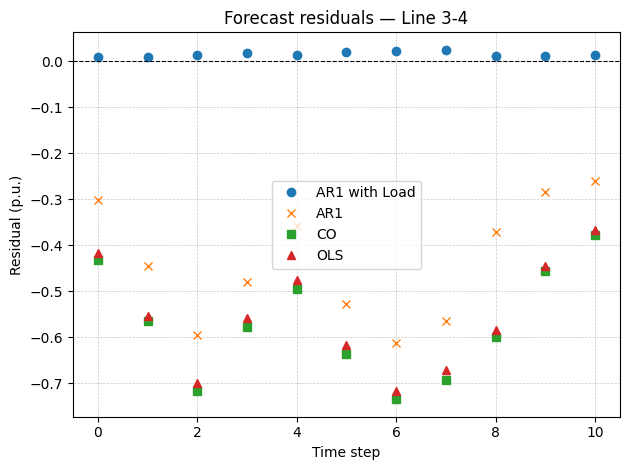

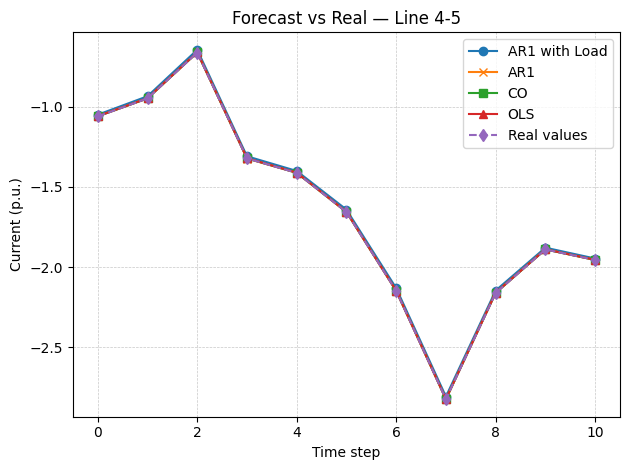

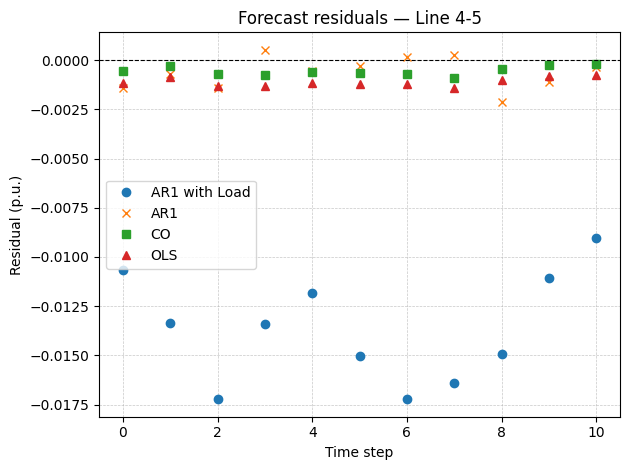

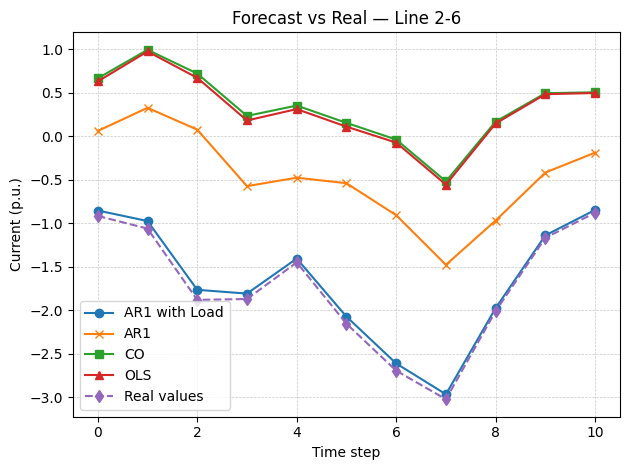

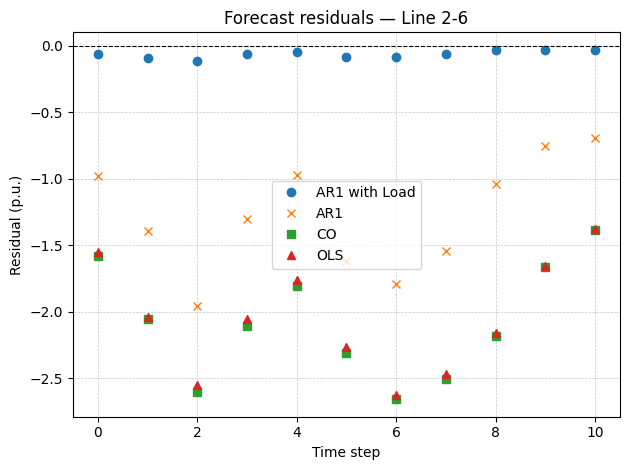

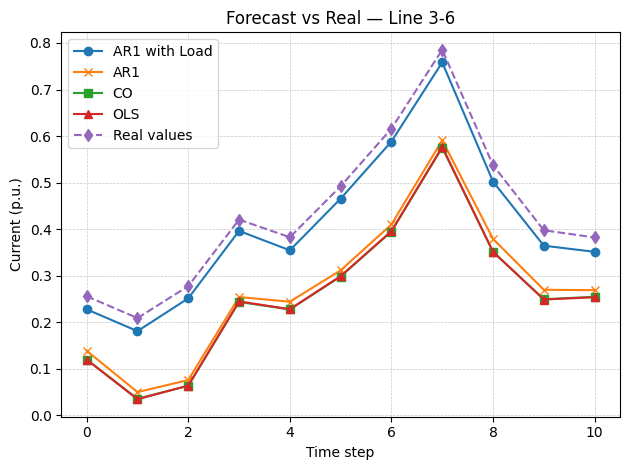

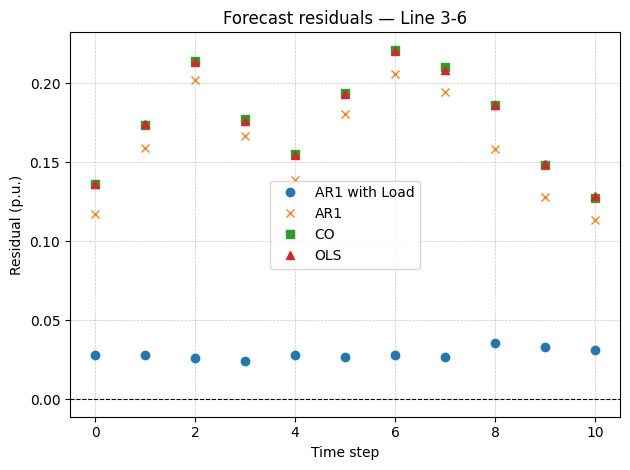

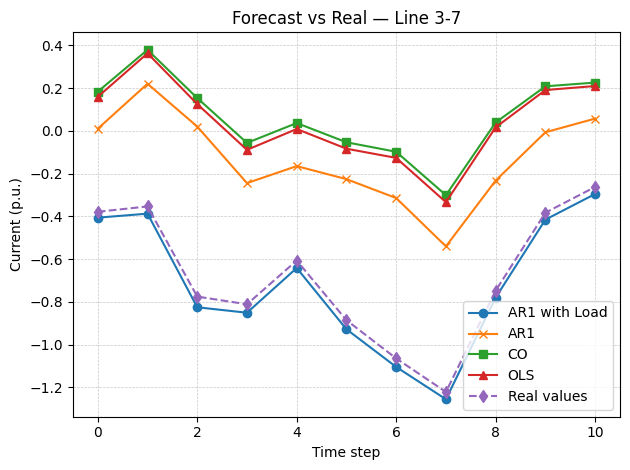

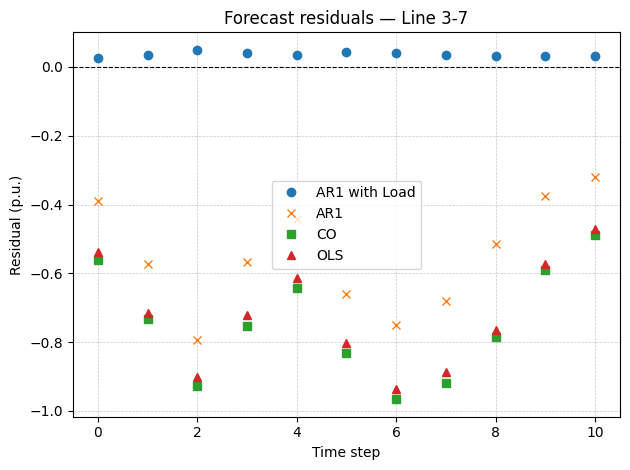

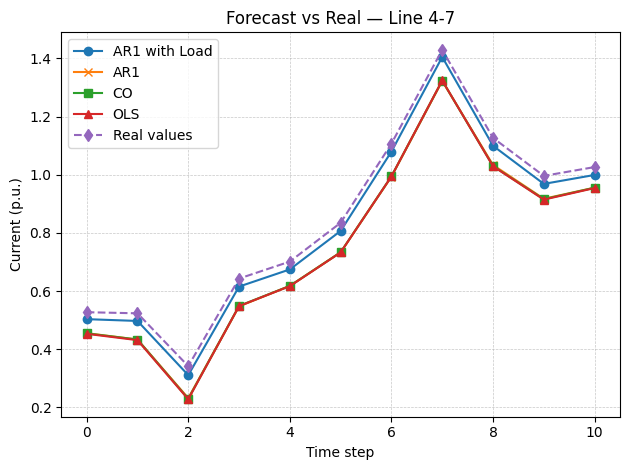

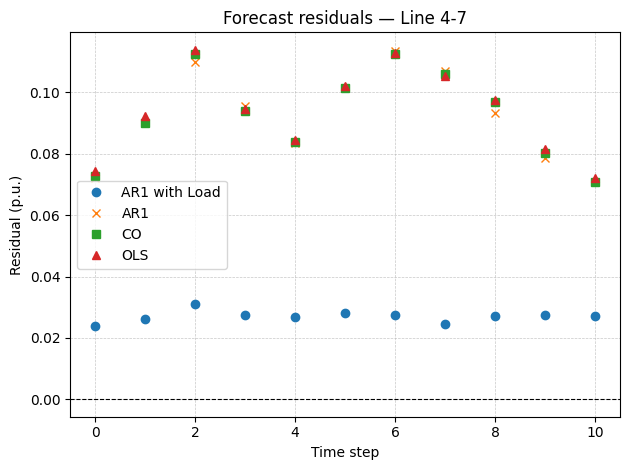

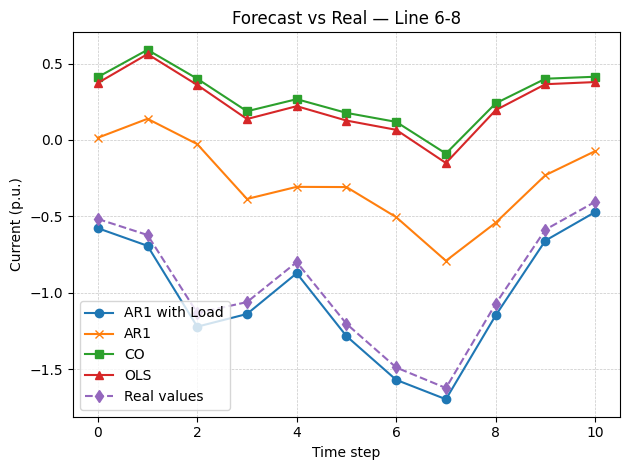

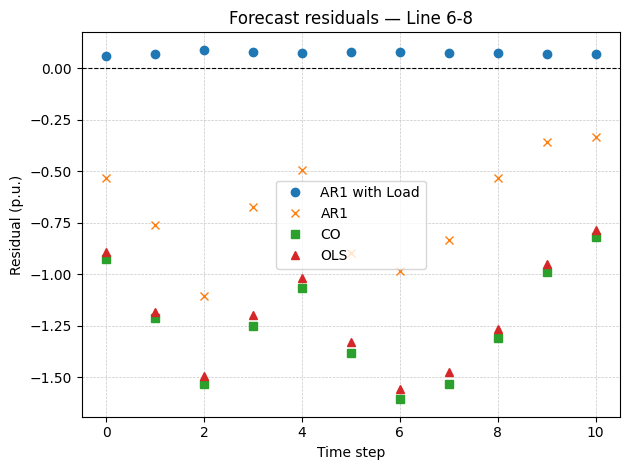

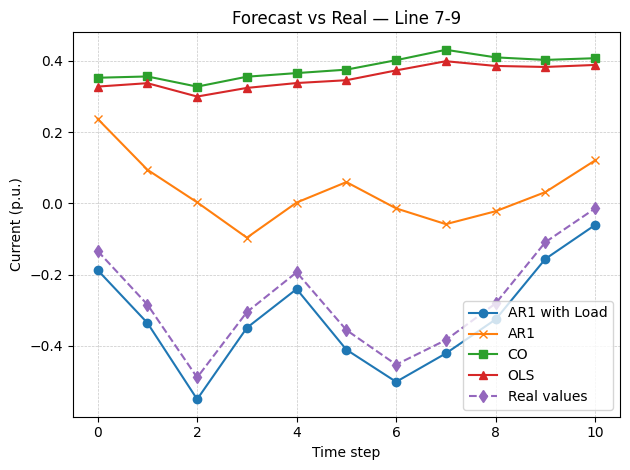

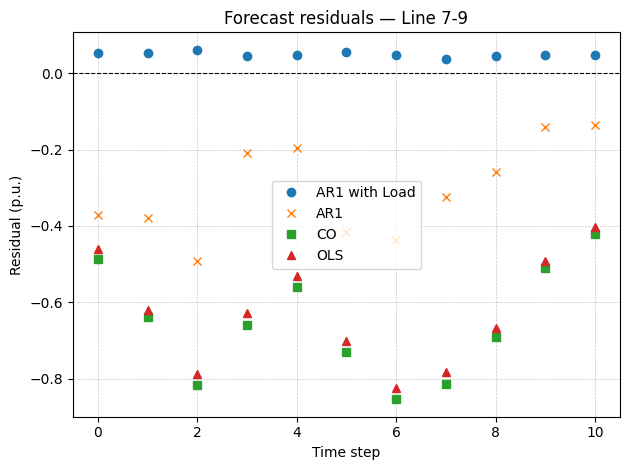

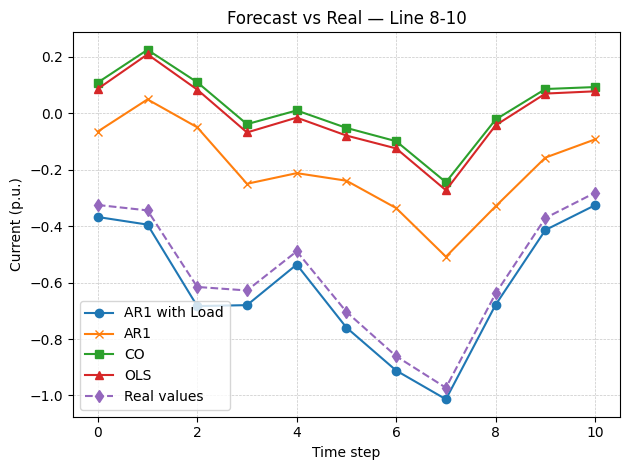

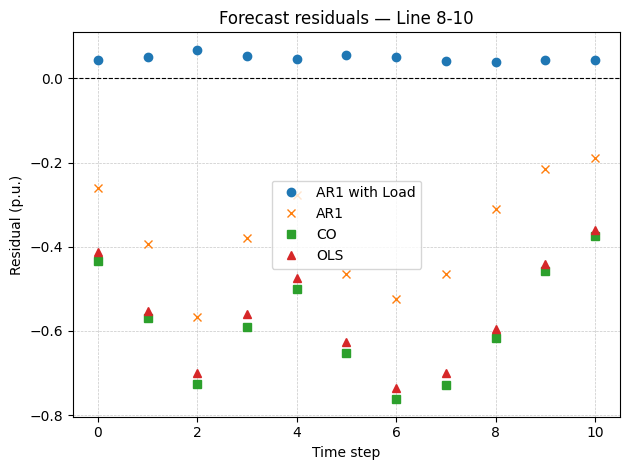

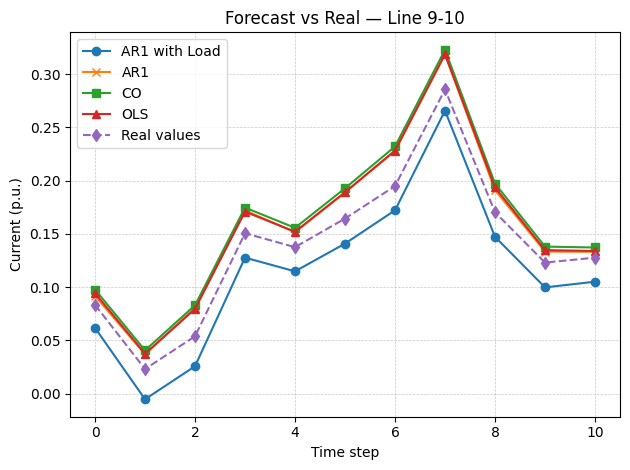

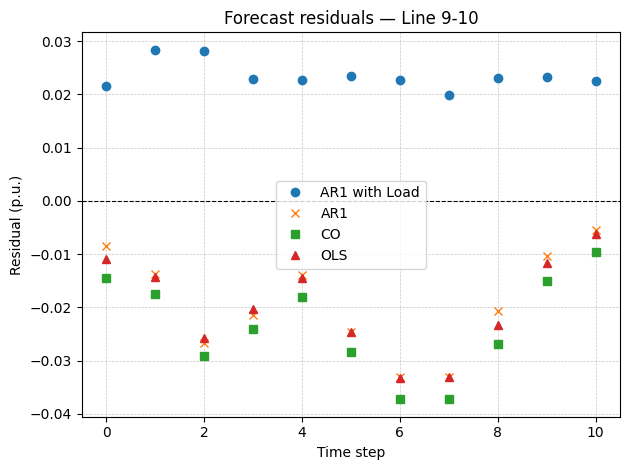

In [93]:
for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]
    real_values = iL[time+1:time+timeForecast]

    b_OLS  = beta_OLS[k]
    b_CO   = beta_CO_all[k]
    b_AR1  = beta_AR1_all[k]
    b_ARL  = beta_AR1L_all[k]

    fc_OLS = (b_OLS[0] + b_OLS[1]*i_pv1[time:time+timeForecast]
                       + b_OLS[2]*i_pv2[time:time+timeForecast])

    fc_CO  = (b_CO[0]  + b_CO[1]*i_pv1[time:time+timeForecast]
                       + b_CO[2]*i_pv2[time:time+timeForecast])

    fc_AR1 = (b_AR1[0] + b_AR1[1]*i_pv1[time+1:time+timeForecast]
                       + b_AR1[2]*i_pv2[time+1:time+timeForecast]
                       + b_AR1[3]*iL[time:time+timeForecast-1])

    fc_ARL = (b_ARL[0] + b_ARL[1]*i_pv1[time+1:time+timeForecast]
                       + b_ARL[2]*i_pv2[time+1:time+timeForecast]
                       + b_ARL[3]*iL[time:time+timeForecast-1]
                       + b_ARL[4]*load_sum[time+1:time+timeForecast])

    x = np.arange(len(fc_AR1))

    # ── Forecast plot ─────────────────────────────────────────────────────────
    plt.figure()
    plt.plot(x, fc_ARL,        label="AR1 with Load", marker='o')
    plt.plot(x, fc_AR1,        label="AR1",           marker='x')
    plt.plot(x, fc_CO[1:],     label="CO",            marker='s')
    plt.plot(x, fc_OLS[1:],    label="OLS",           marker='^')
    plt.plot(x, real_values,   label="Real values",   marker='d', linestyle='--')
    plt.xlabel("Time step")
    plt.ylabel("Current (p.u.)")
    plt.title(f"Forecast vs Real — Line {bi}-{bj}")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ── Residuals plot ────────────────────────────────────────────────────────
    plt.figure()
    plt.plot(x, real_values - fc_ARL,     label="AR1 with Load", marker='o', linestyle='None')
    plt.plot(x, real_values - fc_AR1,     label="AR1",           marker='x', linestyle='None')
    plt.plot(x, real_values - fc_CO[1:],  label="CO",            marker='s', linestyle='None')
    plt.plot(x, real_values - fc_OLS[1:], label="OLS",           marker='^', linestyle='None')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.xlabel("Time step")
    plt.ylabel("Residual (p.u.)")
    plt.title(f"Forecast residuals — Line {bi}-{bj}")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()